# Wildfire Risk Prediction from Multi-Band Satellite Imagery
### A Deep Learning Pipeline for Spatio-Temporal Semantic Segmentation

---

This notebook demonstrates an end-to-end pipeline for predicting wildfire risk at pixel level using multi-band satellite imagery and a temporal deep learning architecture. The study area is mainland Portugal, one of the most fire-affected regions in Europe.

The methodology is intentionally general: the core problem, segmenting multi-channel images using learned spatial and temporal features, is domain-agnostic and maps directly to other image analysis contexts, including multi-parameter fluorescence microscopy and flow cytometry imaging.

**Pipeline overview:**
1. Data retrieval and study area definition
2. Multi-band composite visualisation
3. Spectral index computation and interpretation
4. Temporal signal analysis across the fire season
5. Fire label generation and mask overlay
6. Dataset construction with stratified spatial sampling
7. Model training demonstration (small-scale)
8. Prediction visualisation

In [ ]:
import os
import ee
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import classification_report
import warnings
warnings.filterwarnings('ignore')
from dotenv import load_dotenv

# Local pipeline modules
from gee_utils import (
    build_composite, build_label, fetch_patch,
    get_biweekly_date_ranges, BANDS, N_BANDS
)
from sampling import build_sample_points, get_portugal_geometry

In [ ]:
#requires a GEE account and project ID to run
load_dotenv()
ee.Authenticate(auth_mode='localhost')
ee.Initialize(project=os.getenv("EE_PROJECT_ID"))

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
})

print(f'Band stack ({N_BANDS} bands): {BANDS}')

Environment ready.
Band stack (10 bands): ['Red', 'Green', 'Blue', 'SWIR1', 'SWIR2', 'NDVI', 'NDWI', 'LST', 'Elevation', 'Slope']


## 1 Study Area

The region of interest is mainland Portugal, loaded from the FAO GAUL 2015 administrative boundary dataset. Portugal experiences some of the most severe wildfire seasons in Europe, making it an ideal study area for fire risk modelling.

We focus on a well-documented fire scar near **Leiria / Pedrógão Grande** (central-northern interior), one of the most fire-prone regions in Portugal, to anchor the visualisation sections.

In [19]:
# Load Portugal boundary
portugal = get_portugal_geometry()

# Study patch centre — Pedrógão Grande area, severely burned in June 2017
STUDY_LON = -8.18
STUDY_LAT = 39.97
STUDY_YEAR = 2017
PATCH_SIZE = 64   # pixels at 20 m → ~1.28 km per side

try:
    import folium
    pt_bounds = portugal.bounds().getInfo()['coordinates'][0]
    xs = [c[0] for c in pt_bounds]
    ys = [c[1] for c in pt_bounds]
    m = folium.Map(location=[39.5, -8.0], zoom_start=7, tiles='CartoDB positron')
    folium.Marker(
        [STUDY_LAT, STUDY_LON],
        tooltip='Study patch centre (Pedrógão Grande)',
        icon=folium.Icon(color='red', icon='fire', prefix='fa')
    ).add_to(m)
    display(m)
except ImportError:
    print(f'Study patch centre: lon={STUDY_LON}, lat={STUDY_LAT}')
    print('Install folium for an interactive map: pip install folium')

## 2 Multi-Band Composite Visualisation

Each image in the pipeline is a 10-band composite derived from:
- **Sentinel-2 SR** (10–20 m): Red, Green, Blue, SWIR1 (1.6 µm), SWIR2 (2.2 µm)
- **Derived indices**: NDVI, NDWI
- **MODIS MOD11A1**: Land Surface Temperature (resampled to 20 m)
- **SRTM**: Elevation and Slope

Cloud masking uses the Sentinel-2 QA60 band (cloud and cirrus bits). A median composite over a two-week window further suppresses cloud contamination.

In [20]:
# Fetch pre- and post-fire composites for the study patch
pre_fire_composite  = build_composite('2017-04-01', '2017-04-14')
post_fire_composite = build_composite('2017-10-15', '2017-10-31')

pre_patch  = fetch_patch(pre_fire_composite,  STUDY_LON, STUDY_LAT, PATCH_SIZE)
post_patch = fetch_patch(post_fire_composite, STUDY_LON, STUDY_LAT, PATCH_SIZE)

print(f'Patch shape: {pre_patch.shape}  → (H={PATCH_SIZE}, W={PATCH_SIZE}, C={N_BANDS})')
print(f'Bands: {BANDS}')

Patch shape: (64, 64, 10)  → (H=64, W=64, C=10)
Bands: ['Red', 'Green', 'Blue', 'SWIR1', 'SWIR2', 'NDVI', 'NDWI', 'LST', 'Elevation', 'Slope']


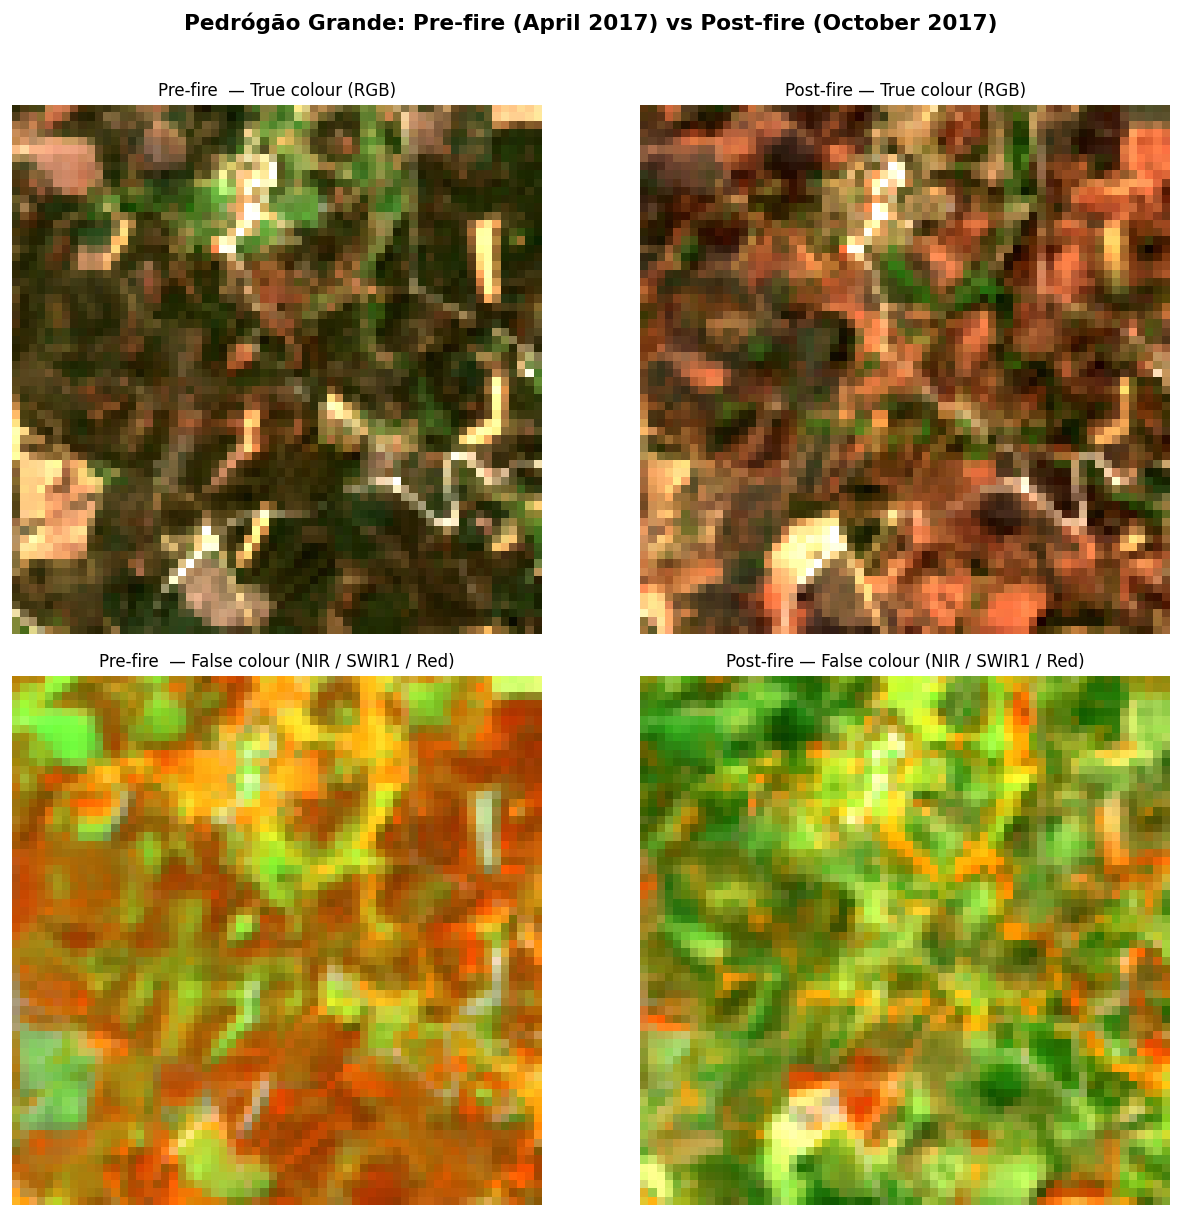

False colour: healthy vegetation = bright red; burn scars = dark brown/grey


In [21]:
def percentile_stretch(arr, lo=2, hi=98):
    """Percentile contrast stretch for visualisation. Works per-band."""
    p_lo, p_hi = np.percentile(arr, lo), np.percentile(arr, hi)
    return np.clip((arr - p_lo) / (p_hi - p_lo + 1e-6), 0, 1)


def make_rgb(patch):
    """Extract and stretch the Red/Green/Blue bands (indices 0-2)."""
    rgb = patch[:, :, :3].copy()
    return percentile_stretch(rgb)


def make_false_colour(patch):
    """NIR-SWIR1-Red false colour composite to highlight vegetation stress."""
    # NDVI is index 5, SWIR1 index 3, Red index 0  — recompose as (NIR, SWIR1, Red)
    # Approximate NIR from NDVI and Red: NIR = (1+NDVI)*Red / (1-NDVI+eps)
    ndvi = patch[:, :, 5]
    red  = patch[:, :, 0]
    nir  = red * (1 + ndvi) / np.clip(1 - ndvi, 1e-3, None)
    fc   = np.stack([nir, patch[:, :, 3], red], axis=-1)
    return percentile_stretch(fc)


fig, axes = plt.subplots(2, 2, figsize=(11, 10))
fig.suptitle(
    'Pedrógão Grande: Pre-fire (April 2017) vs Post-fire (October 2017)',
    fontsize=13, fontweight='bold', y=1.01
)

panels = [
    (axes[0, 0], make_rgb(pre_patch),          'Pre-fire  — True colour (RGB)'),
    (axes[0, 1], make_rgb(post_patch),          'Post-fire — True colour (RGB)'),
    (axes[1, 0], make_false_colour(pre_patch),  'Pre-fire  — False colour (NIR / SWIR1 / Red)'),
    (axes[1, 1], make_false_colour(post_patch), 'Post-fire — False colour (NIR / SWIR1 / Red)'),
]

for ax, img, title in panels:
    ax.imshow(img)
    ax.set_title(title, fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.savefig('fig_rgb_comparison.png', bbox_inches='tight', dpi=150)
plt.show()
print('False colour: healthy vegetation = bright red; burn scars = dark brown/grey')

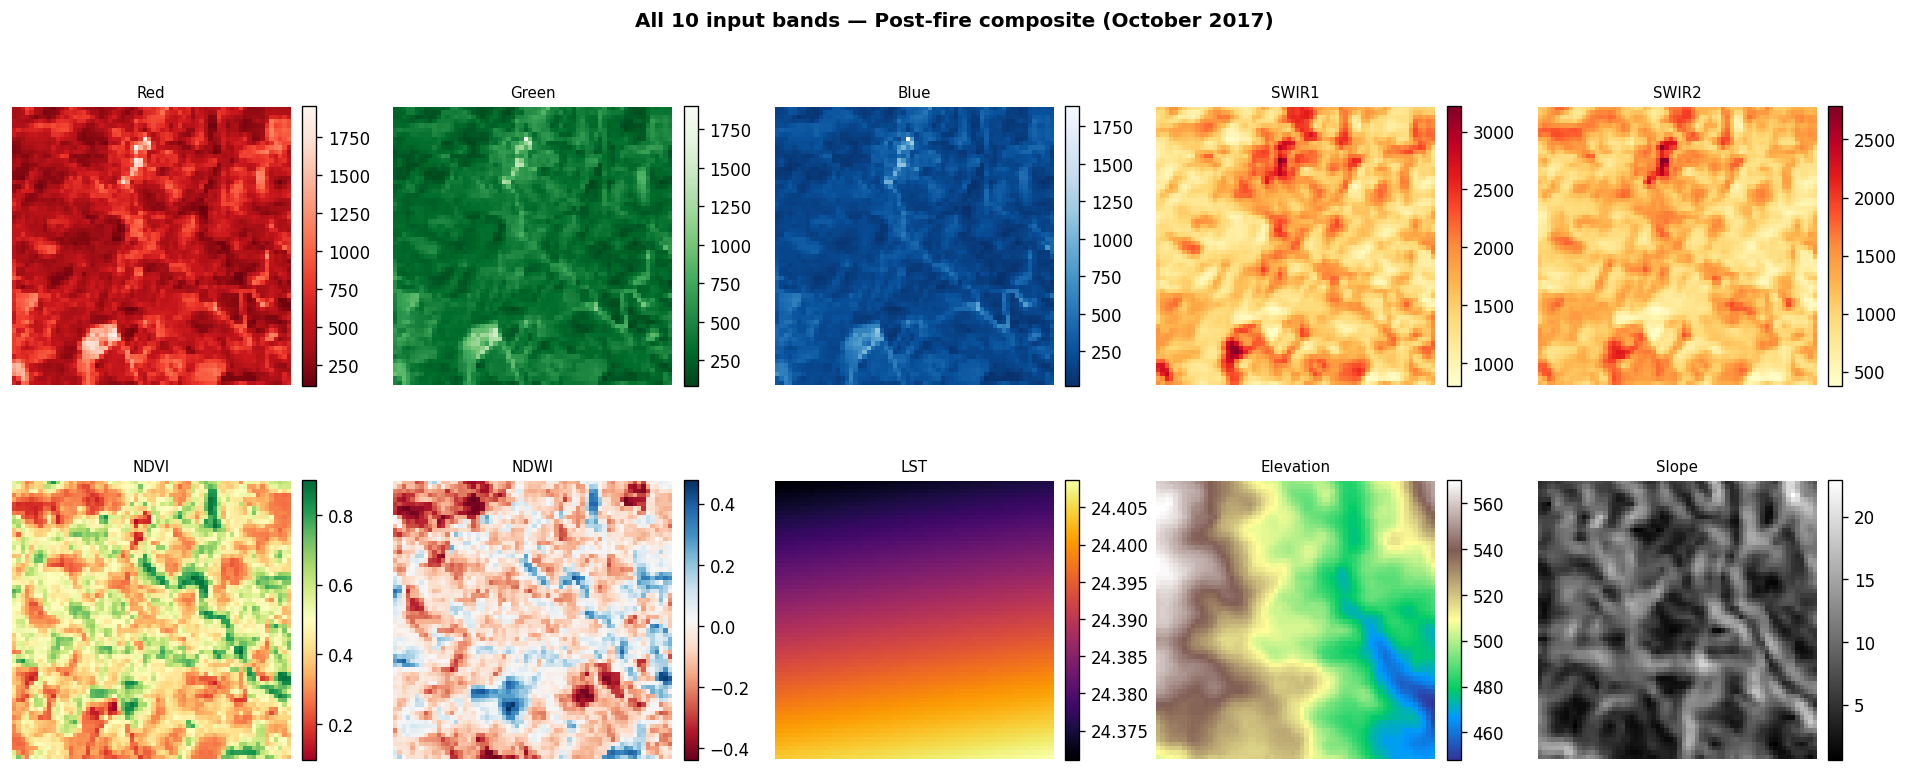

In [22]:
# Visualise all 10 bands side by side for the post-fire patch
band_cmaps = {
    'Red': 'Reds_r', 'Green': 'Greens_r', 'Blue': 'Blues_r',
    'SWIR1': 'YlOrRd', 'SWIR2': 'YlOrRd',
    'NDVI': 'RdYlGn', 'NDWI': 'RdBu',
    'LST': 'inferno', 'Elevation': 'terrain', 'Slope': 'gray',
}

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
fig.suptitle('All 10 input bands — Post-fire composite (October 2017)', fontsize=12, fontweight='bold')

for ax, band, idx in zip(axes.flat, BANDS, range(N_BANDS)):
    data = post_patch[:, :, idx]
    im = ax.imshow(data, cmap=band_cmaps[band])
    ax.set_title(band, fontsize=9)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig('fig_all_bands.png', bbox_inches='tight', dpi=150)
plt.show()

## 3 Spectral Indices

Three indices in the band stack carry the most fire-relevant spectral information:

| Index | Formula | Fire relevance |
|-------|---------|----------------|
| **NDVI** | (NIR − Red) / (NIR + Red) | Vegetation greenness; declines under drought stress |
| **NDWI** | (NIR − SWIR1) / (NIR + SWIR1) | Vegetation water content; low values indicate desiccated fuel load |
| **LST** | MODIS thermal (°C) | Surface temperature; elevated values in desiccated patches signal high fire weather conditions |

The SWIR bands (1.6 µm and 2.2 µm) are also directly sensitive to active combustion and char, making them useful for both risk prediction and burn scar detection.

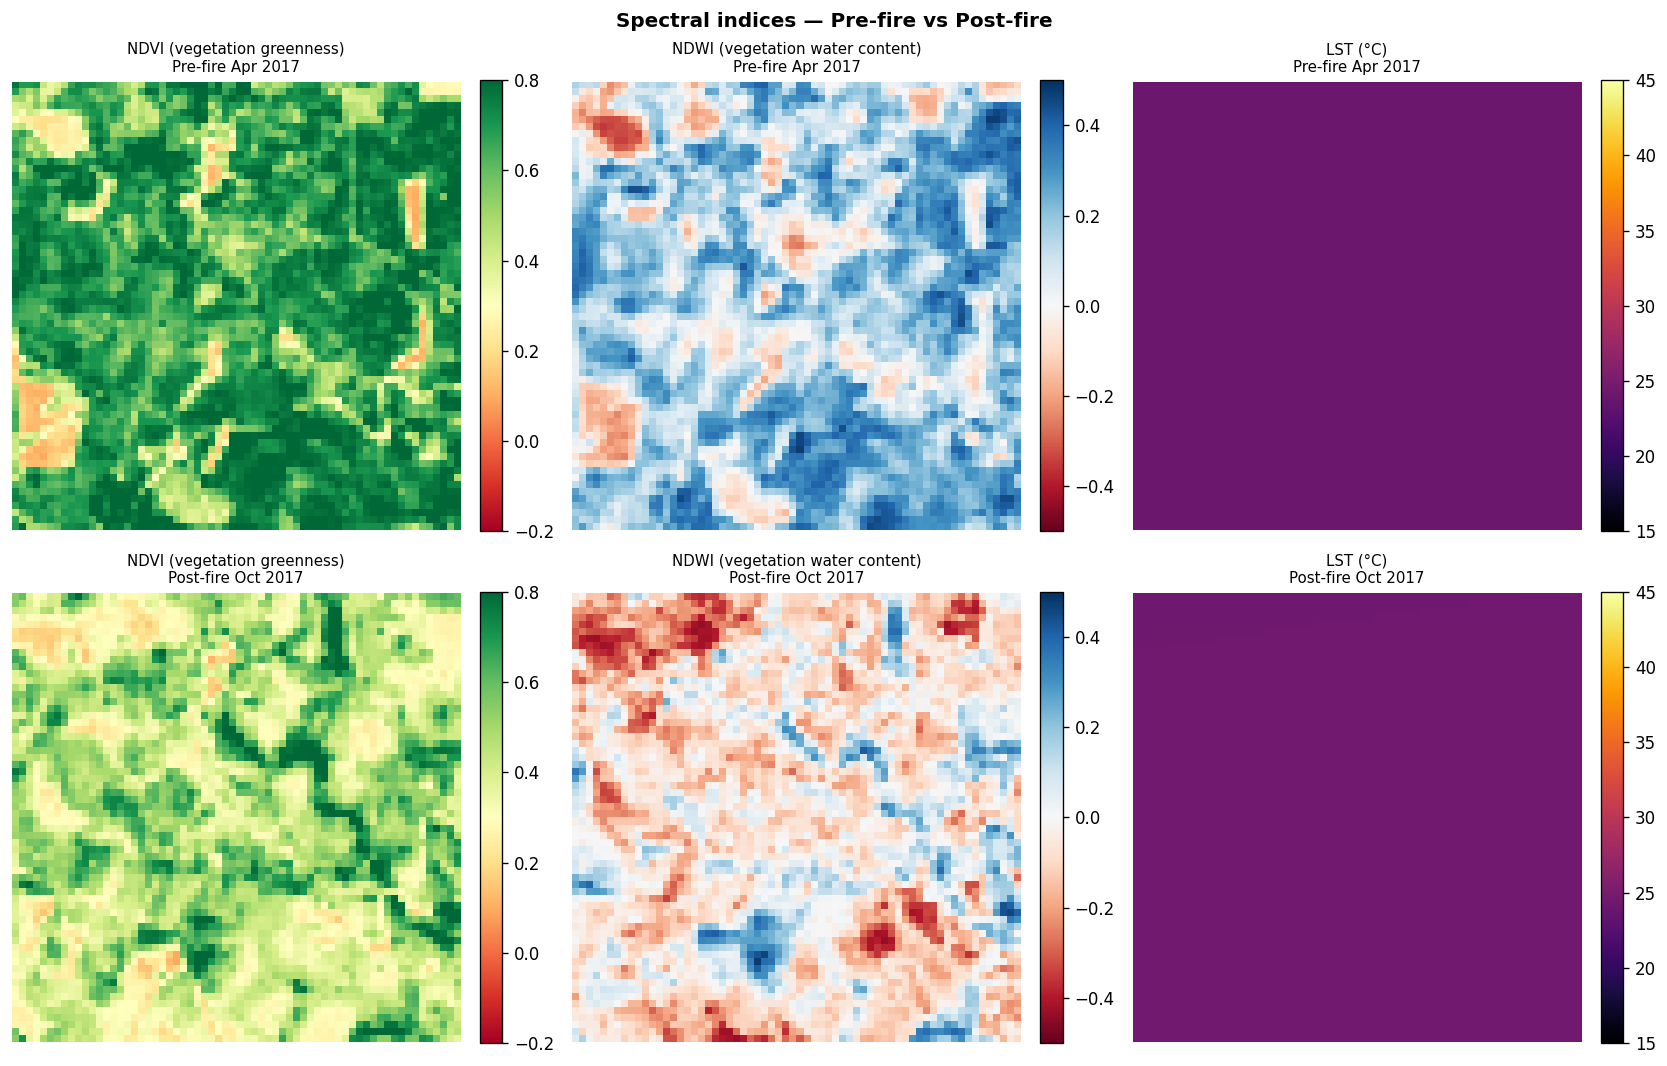

In [23]:
band_idx = {b: i for i, b in enumerate(BANDS)}

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
fig.suptitle('Spectral indices — Pre-fire vs Post-fire', fontsize=12, fontweight='bold')

index_cfg = [
    ('NDVI',      'RdYlGn', (-0.2, 0.8), 'NDVI (vegetation greenness)'),
    ('NDWI',      'RdBu',   (-0.5, 0.5), 'NDWI (vegetation water content)'),
    ('LST',       'inferno', (15, 45),    'LST (°C)'),
]

for col, (band, cmap, vrange, label) in enumerate(index_cfg):
    for row, (patch, period) in enumerate([(pre_patch, 'Pre-fire Apr 2017'),
                                            (post_patch, 'Post-fire Oct 2017')]):
        ax  = axes[row, col]
        data = patch[:, :, band_idx[band]]
        im   = ax.imshow(data, cmap=cmap, vmin=vrange[0], vmax=vrange[1])
        ax.set_title(f'{label}\n{period}', fontsize=9)
        ax.axis('off')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig('fig_indices.png', bbox_inches='tight', dpi=150)
plt.show()

## 4 Temporal Signal Analysis

The core motivation for a temporal model is that fire risk is encoded in the *trajectory* of spectral signals, not a single snapshot. A location with declining NDVI, falling NDWI, and rising LST over several weeks represents a fundamentally different risk profile from a location that simply looks dry on one date.

Below we fetch a sequence of bi-weekly composites across the 2017 fire season for the study patch and plot the per-pixel mean trajectories of NDVI, NDWI, and LST. The ignition date (June 17, 2017) is marked for reference.

In [24]:
# Fetch bi-weekly composites across the 2017 fire season
date_ranges = get_biweekly_date_ranges(STUDY_YEAR)
print(f'{len(date_ranges)} bi-weekly periods for {STUDY_YEAR}:')
for start, end in date_ranges:
    print(f'  {start}  →  {end}')

16 bi-weekly periods for 2017:
  2017-04-01  →  2017-04-15
  2017-04-15  →  2017-04-29
  2017-04-29  →  2017-05-13
  2017-05-13  →  2017-05-27
  2017-05-27  →  2017-06-10
  2017-06-10  →  2017-06-24
  2017-06-24  →  2017-07-08
  2017-07-08  →  2017-07-22
  2017-07-22  →  2017-08-05
  2017-08-05  →  2017-08-19
  2017-08-19  →  2017-09-02
  2017-09-02  →  2017-09-16
  2017-09-16  →  2017-09-30
  2017-09-30  →  2017-10-14
  2017-10-14  →  2017-10-28
  2017-10-28  →  2017-10-31


In [25]:
# Fetch the full sequence
print('Fetching temporal sequence from GEE...')
sequence_patches = []

for i, (start, end) in enumerate(date_ranges):
    composite = build_composite(start, end)
    patch     = fetch_patch(composite, STUDY_LON, STUDY_LAT, PATCH_SIZE)
    sequence_patches.append(patch)
    print(f'  [{i+1:02d}/{len(date_ranges)}] {start} → {end}  patch shape: {patch.shape}')

sequence = np.stack(sequence_patches, axis=0)   # (T, H, W, C)
print(f'\nSequence shape: {sequence.shape}  →  (T={sequence.shape[0]}, H, W, C={N_BANDS})')

Fetching temporal sequence from GEE...
  [01/16] 2017-04-01 → 2017-04-15  patch shape: (64, 64, 10)
  [02/16] 2017-04-15 → 2017-04-29  patch shape: (64, 64, 10)
  [03/16] 2017-04-29 → 2017-05-13  patch shape: (64, 64, 10)
  [04/16] 2017-05-13 → 2017-05-27  patch shape: (64, 64, 10)
  [05/16] 2017-05-27 → 2017-06-10  patch shape: (64, 64, 10)
  [06/16] 2017-06-10 → 2017-06-24  patch shape: (64, 64, 10)
  [07/16] 2017-06-24 → 2017-07-08  patch shape: (64, 64, 10)
  [08/16] 2017-07-08 → 2017-07-22  patch shape: (64, 64, 10)
  [09/16] 2017-07-22 → 2017-08-05  patch shape: (64, 64, 10)
  [10/16] 2017-08-05 → 2017-08-19  patch shape: (64, 64, 10)
  [11/16] 2017-08-19 → 2017-09-02  patch shape: (64, 64, 10)
  [12/16] 2017-09-02 → 2017-09-16  patch shape: (64, 64, 10)
  [13/16] 2017-09-16 → 2017-09-30  patch shape: (64, 64, 10)
  [14/16] 2017-09-30 → 2017-10-14  patch shape: (64, 64, 10)
  [15/16] 2017-10-14 → 2017-10-28  patch shape: (64, 64, 10)
  [16/16] 2017-10-28 → 2017-10-31  patch shape

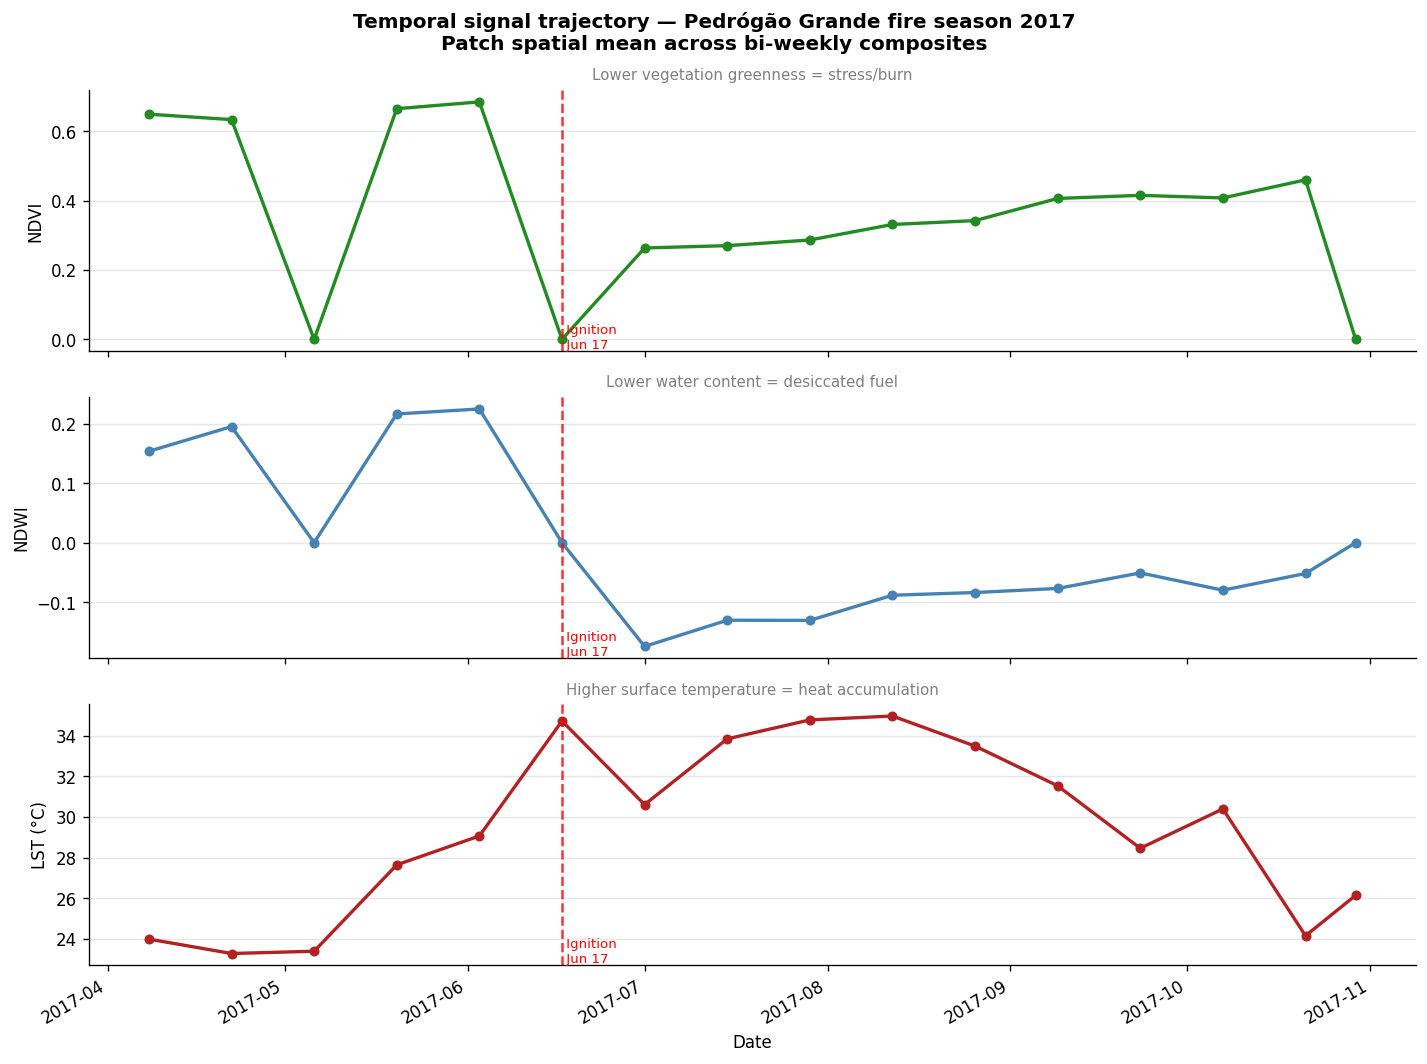

In [27]:
# Mid-point dates for x-axis labels
from datetime import datetime, timedelta

mid_dates = [
    datetime.strptime(s, '%Y-%m-%d') + (datetime.strptime(e, '%Y-%m-%d') - datetime.strptime(s, '%Y-%m-%d')) / 2
    for s, e in date_ranges
]
ignition = datetime(2017, 6, 17)  # Pedrógão Grande ignition date

# Spatial mean across the patch per timestep
ndvi_ts = sequence[:, :, :, band_idx['NDVI']].mean(axis=(1, 2))
ndwi_ts = sequence[:, :, :, band_idx['NDWI']].mean(axis=(1, 2))
lst_ts  = sequence[:, :, :, band_idx['LST']].mean(axis=(1, 2))

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
fig.suptitle(
    'Temporal signal trajectory — Pedrógão Grande fire season 2017\n'
    'Patch spatial mean across bi-weekly composites',
    fontsize=12, fontweight='bold'
)

cfg = [
    (axes[0], ndvi_ts, 'NDVI', 'forestgreen',   'Lower vegetation greenness = stress/burn'),
    (axes[1], ndwi_ts, 'NDWI', 'steelblue',     'Lower water content = desiccated fuel'),
    (axes[2], lst_ts,  'LST (°C)', 'firebrick',  'Higher surface temperature = heat accumulation'),
]

for ax, ts, ylabel, colour, note in cfg:
    ax.plot(mid_dates, ts, color=colour, linewidth=2, marker='o', markersize=5)
    ax.axvline(ignition, color='red', linewidth=1.5, linestyle='--', alpha=0.8)
    ax.text(ignition, ax.get_ylim()[0], ' Ignition\n Jun 17', color='red',
            fontsize=8, va='bottom')
    ax.set_ylabel(ylabel)
    ax.set_title(note, fontsize=9, color='gray')
    ax.grid(axis='y', alpha=0.3)

axes[-1].set_xlabel('Date')
fig.autofmt_xdate(rotation=30)
plt.tight_layout()
plt.savefig('fig_temporal_signal.png', bbox_inches='tight', dpi=150)
plt.show()

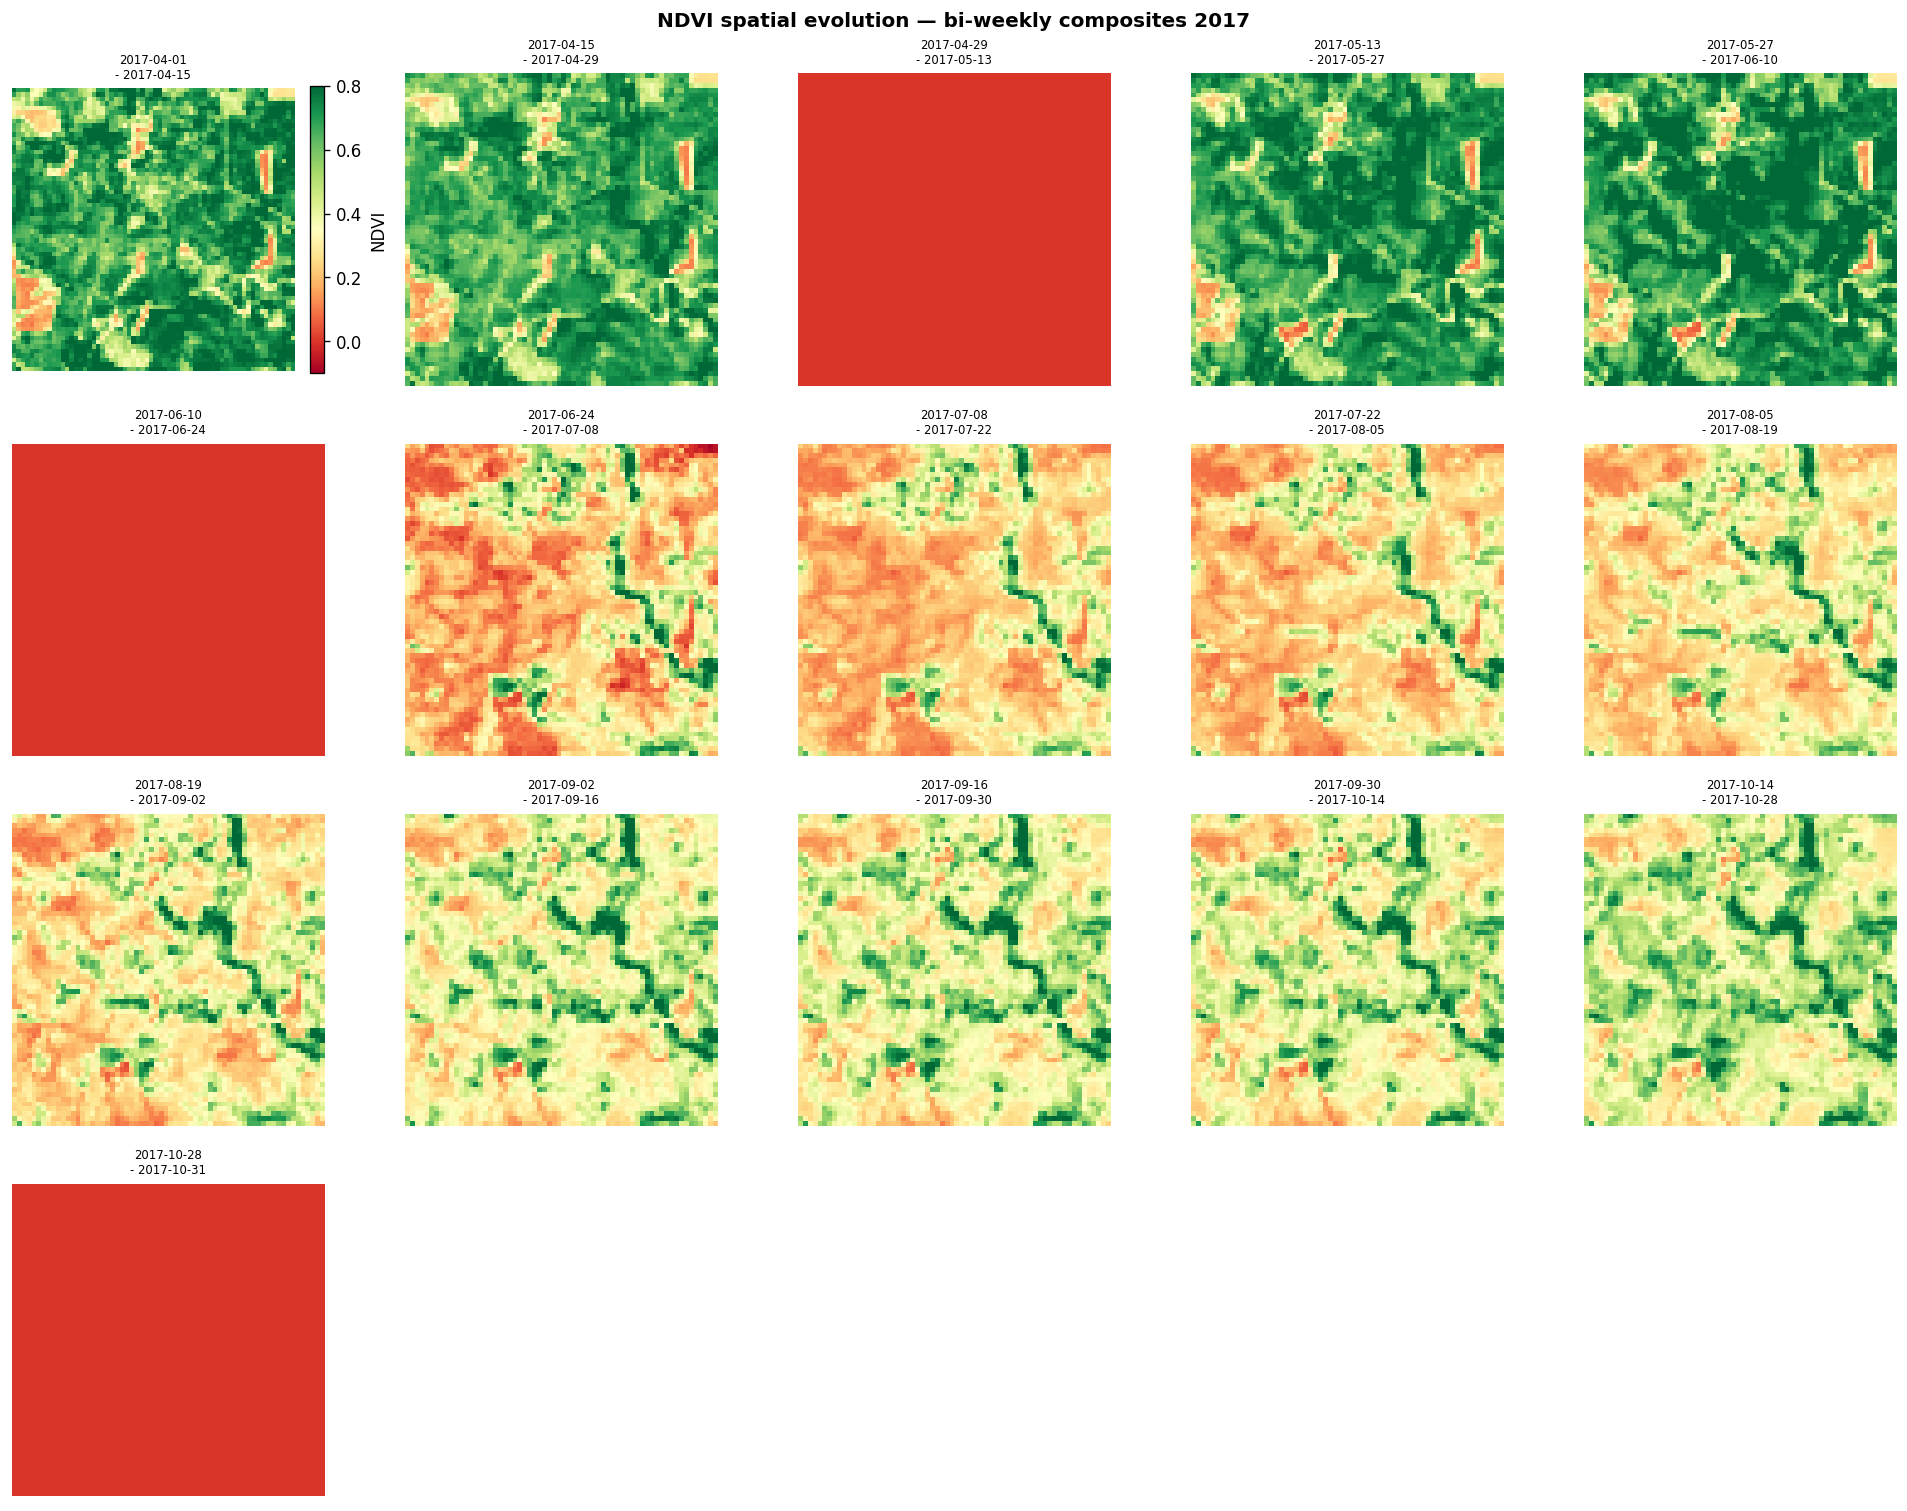

In [28]:
# Spatial NDVI maps across the sequence — shows the burn scar developing
n_periods = len(date_ranges)
n_cols    = 5
n_rows    = int(np.ceil(n_periods / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.2))
fig.suptitle('NDVI spatial evolution — bi-weekly composites 2017', fontsize=12, fontweight='bold')

for i, ax in enumerate(axes.flat):
    if i < n_periods:
        data = sequence[i, :, :, band_idx['NDVI']]
        im   = ax.imshow(data, cmap='RdYlGn', vmin=-0.1, vmax=0.8)
        start, end = date_ranges[i]
        ax.set_title(f'{start}\n- {end}', fontsize=7)
        ax.axis('off')
        if i == 0:
            plt.colorbar(im, ax=ax, fraction=0.046, label='NDVI')
        # Mark the post-ignition periods
        if datetime.strptime(start, '%Y-%m-%d') >= ignition:
            for spine in ax.spines.values():
                spine.set_edgecolor('red')
                spine.set_linewidth(2)
    else:
        ax.axis('off')

#fig.text(0.5, -0.01, 'Red borders indicate post-ignition periods', ha='center',
        # fontsize=9, color='red')
plt.tight_layout()
plt.savefig('fig_ndvi_sequence.png', bbox_inches='tight', dpi=150)
plt.show()

## 5 Fire Labels and Mask Overlay

Labels are derived from the **MODIS MCD64A1** burned area product (500 m, monthly). Any pixel confirmed burned within a target period is assigned label `1`; all others `0`. The product is reprojected to the Sentinel-2 20 m UTM grid using nearest-neighbour resampling to preserve the binary nature of the mask.

Burned pixel fraction: 97.9%


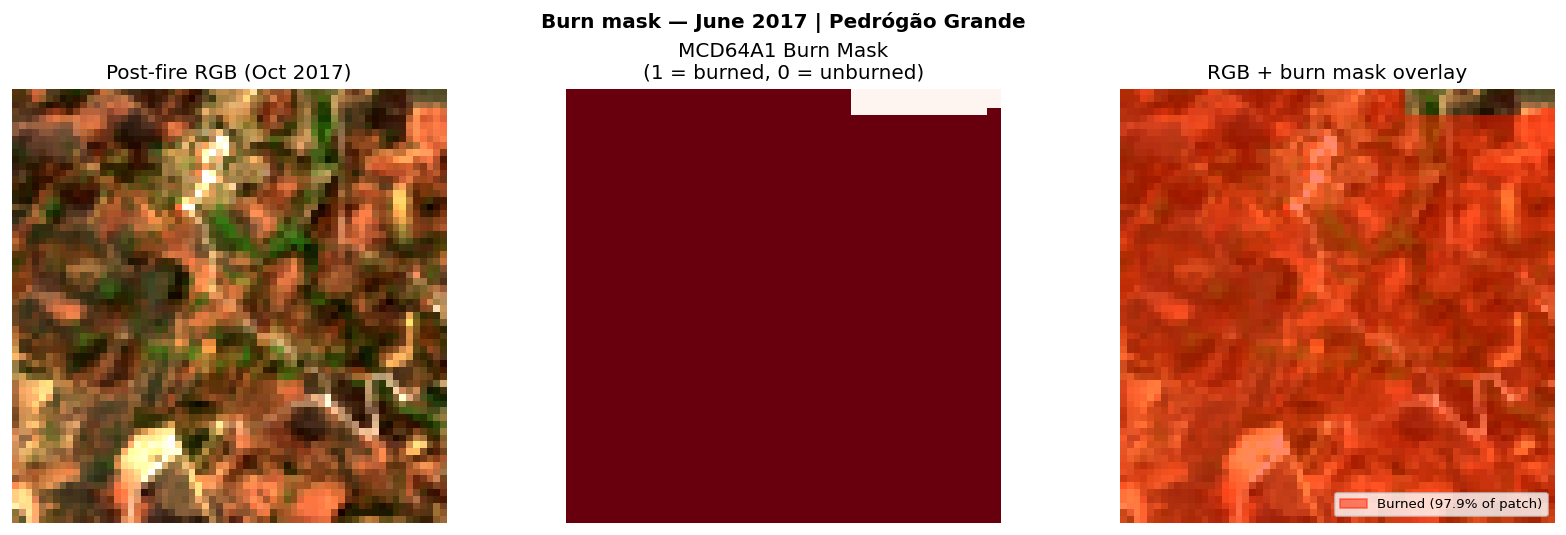

In [29]:
# Fetch the burn mask for the 2017 ignition period
label_img   = build_label('2017-06-01', '2017-07-01')
label_patch = fetch_patch(label_img, STUDY_LON, STUDY_LAT, PATCH_SIZE)
label_patch = label_patch[:, :, 0]   # single band → (H, W)

burned_frac = label_patch.mean() * 100
print(f'Burned pixel fraction: {burned_frac:.1f}%')

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
fig.suptitle('Burn mask — June 2017 | Pedrógão Grande', fontsize=12, fontweight='bold')

# Post-fire RGB
axes[0].imshow(make_rgb(post_patch))
axes[0].set_title('Post-fire RGB (Oct 2017)')
axes[0].axis('off')

# Binary burn mask
axes[1].imshow(label_patch, cmap='Reds', vmin=0, vmax=1)
axes[1].set_title('MCD64A1 Burn Mask\n(1 = burned, 0 = unburned)')
axes[1].axis('off')

# Overlay mask on RGB
rgb_overlay = make_rgb(post_patch).copy()
mask_rgba   = np.zeros((*label_patch.shape, 4))
mask_rgba[label_patch == 1] = [1, 0.15, 0, 0.55]   # red, semi-transparent
axes[2].imshow(rgb_overlay)
axes[2].imshow(mask_rgba)
axes[2].set_title('RGB + burn mask overlay')
axes[2].axis('off')

legend = [mpatches.Patch(color=(1, 0.15, 0, 0.55), label=f'Burned ({burned_frac:.1f}% of patch)')]
axes[2].legend(handles=legend, loc='lower right', fontsize=8)

plt.tight_layout()
plt.savefig('fig_burn_mask.png', bbox_inches='tight', dpi=150)
plt.show()

## 6 Dataset Construction

The training dataset is constructed using a stratified spatial sampling strategy:

- **Fire-positive patches** are sampled from confirmed burned pixels (MCD64A1), ensuring every positive sample has a real fire event
- **Non-fire patches** are drawn from unburned pixels at a 3:1 ratio, partly mitigating class imbalance
- **Spatial block split**: Portugal is divided into a ~0.5° grid (~50 km cells). Blocks are randomly assigned 80/20 to train/validation, ensuring geographic separation between splits

For this demonstration we use a small cached dataset of 50 patches to enable a training run without GEE streaming latency.

In [4]:
# Build sample points for a small demo (2 years, small n)
DEMO_YEARS         = [2016, 2017]
DEMO_FIRE_PER_YEAR = 15
SEQUENCE_LENGTH    = 6

print('Sampling patch centre points from GEE...')
train_pts, val_pts = build_sample_points(
    DEMO_YEARS,
    fire_per_year=DEMO_FIRE_PER_YEAR,
    nonfire_ratio=3.0,
    verbose=True,
)

Sampling patch centre points from GEE...
  2016: 15 fire points sampled
  2017: 15 fire points sampled
Sampled     30 fire points    across 2 years
Sampled     86 non-fire points across 2 years
Grid     40 occupied 0.5° blocks  →  8 val blocks (20%)
Split →     88 train  |    28 val


In [5]:
from gee_utils import get_biweekly_date_ranges
import random

_date_cache = {
    yr: get_biweekly_date_ranges(yr) for yr in DEMO_YEARS
}

def fetch_sample(lon, lat, year, sequence_length=SEQUENCE_LENGTH, patch_size=PATCH_SIZE):
    """Fetch one (inputs, label) sample from GEE, returns numpy arrays or None."""
    ranges = _date_cache[year]
    if len(ranges) < sequence_length + 1:
        return None
    i = random.randint(0, len(ranges) - sequence_length - 1)
    input_ranges = ranges[i : i + sequence_length]
    label_range  = ranges[i + sequence_length]

    try:
        frames = []
        for s, e in input_ranges:
            patch = fetch_patch(build_composite(s, e), lon, lat, patch_size)
            frames.append(patch)
        inputs = np.stack(frames, axis=0)                              # (T, H, W, C)
        label  = fetch_patch(build_label(*label_range), lon, lat, patch_size)[:, :, 0]  # (H, W)
        return inputs, label
    except Exception as exc:
        print(f'  Skipped ({lon:.3f}, {lat:.3f}, {year}): {exc}')
        return None


def build_cache(points, max_samples=None, label=''):
    """Fetch and cache a list of samples as numpy arrays."""
    inputs_list, labels_list = [], []
    pts = points[:max_samples] if max_samples else points
    for i, (lon, lat, yr) in enumerate(pts):
        result = fetch_sample(lon, lat, yr)
        if result:
            inputs_list.append(result[0])
            labels_list.append(result[1])
        print(f'  {label} [{i+1}/{len(pts)}] cached {len(inputs_list)} samples', end='\r')
    print()
    return np.stack(inputs_list), np.stack(labels_list)


print('Caching training patches...')
train_inputs, train_labels = build_cache(train_pts, label='train')
print('Caching validation patches...')
val_inputs, val_labels = build_cache(val_pts, label='val')

print(f'\nTrain: {train_inputs.shape}  labels: {train_labels.shape}')
print(f'Val:   {val_inputs.shape}  labels: {val_labels.shape}')
print(f'Train fire pixel fraction: {train_labels.mean():.3f}')
print(f'Val   fire pixel fraction: {val_labels.mean():.3f}')

Caching training patches...
  train [88/88] cached 88 samples
Caching validation patches...
  val [28/28] cached 28 samples

Train: (88, 6, 64, 64, 10)  labels: (88, 64, 64)
Val:   (28, 6, 64, 64, 10)  labels: (28, 64, 64)
Train fire pixel fraction: 0.031
Val   fire pixel fraction: 0.089


In [13]:
np.save('train_inputs.npy', train_inputs)
np.save('train_labels.npy', train_labels)
np.save('val_inputs.npy',   val_inputs)
np.save('val_labels.npy',   val_labels)

In [5]:
train_inputs = np.load('train_inputs.npy')
train_labels = np.load('train_labels.npy')
val_inputs   = np.load('val_inputs.npy')
val_labels   = np.load('val_labels.npy')

## 7 Model: ConvLSTM Segmentation

Standard LSTMs process sequential data as flat vectors, discarding spatial structure entirely. A fully connected approach would require flattening each 64×64 image into 4,096 values per band, losing all neighbourhood context that makes image segmentation meaningful.

ConvLSTM addresses this by replacing the matrix multiplications in the LSTM gate equations with convolutions, so the hidden state at each timestep is a spatial feature map rather than a flat vector. The model processes each bi-weekly composite as a grid of local receptive fields, propagating spatial context forward through time. The result is a hidden state that simultaneously encodes where vegetation stress is occurring and how that pattern has evolved across the season, information that neither a purely spatial model nor a purely temporal model could capture alone.

This makes ConvLSTM a natural fit for the fire risk problem: the discriminative signal is a spatio-temporal trajectory, not a static snapshot.

```
Input:  (B, T, C, H, W)  — batch of T bi-weekly composites
  -  ConvLSTM encoder — learns temporal dynamics in feature space
  -  Final hidden state (B, hidden, H, W)
  -  Conv decoder — upsamples to full resolution
Output: (B, 1, H, W)  — per-pixel fire probability
```

**Note:** This is a small-scale demonstration. A production model would use the U-TAE architecture with a deeper encoder, temporal attention, and training across the full 10-year dataset. The goal here is to validate the pipeline end-to-end and show the model learning a meaningful signal despite the inherent difficulty of fire prediction.

In [ ]:
class ConvLSTMCell(nn.Module):
    """Single ConvLSTM cell operating on spatial feature maps."""

    def __init__(self, in_channels: int, hidden_channels: int, kernel_size: int = 3):
        super().__init__()
        pad = kernel_size // 2
        self.hidden_channels = hidden_channels
        # Combined gate convolution: input + hidden = 4 gates
        self.conv = nn.Conv2d(
            in_channels + hidden_channels,
            4 * hidden_channels,
            kernel_size, padding=pad
        )

    def forward(self, x, h, c):
        combined = torch.cat([x, h], dim=1)
        gates    = self.conv(combined)
        i, f, o, g = gates.chunk(4, dim=1)
        i, f, o = torch.sigmoid(i), torch.sigmoid(f), torch.sigmoid(o)
        g = torch.tanh(g)
        c_next = f * c + i * g
        h_next = o * torch.tanh(c_next)
        return h_next, c_next

    def init_hidden(self, batch, h, w, device):
        zeros = torch.zeros(batch, self.hidden_channels, h, w, device=device)
        return zeros, zeros.clone()


class FireRiskModel(nn.Module):
    """
    ConvLSTM encoder + lightweight convolutional decoder for
    per-pixel fire probability prediction.

    Input:  (B, T, C, H, W)
    Output: (B, 1, H, W)  — sigmoid-activated probability map
    """

    def __init__(self, in_channels: int = N_BANDS, hidden: int = 32):
        super().__init__()
        self.encoder = ConvLSTMCell(in_channels, hidden)
        self.decoder = nn.Sequential(
            nn.Conv2d(hidden, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.Conv2d(16, 1, kernel_size=1),
        )

    def forward(self, x):
        B, T, C, H, W = x.shape
        h, c = self.encoder.init_hidden(B, H, W, x.device)
        for t in range(T):
            h, c = self.encoder(x[:, t], h, c)
        return torch.sigmoid(self.decoder(h))


model = FireRiskModel(in_channels=N_BANDS, hidden=32)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model parameters: {n_params:,}')
print(model)

Model parameters: 53,185
FireRiskModel(
  (encoder): ConvLSTMCell(
    (conv): Conv2d(42, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
  (decoder): Sequential(
    (0): Conv2d(32, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(16, 1, kernel_size=(1, 1), stride=(1, 1))
  )
)


In [ ]:
def normalise(x, eps=1e-6):
    """Per-band z-score normalisation across the batch."""
    mean = x.mean(dim=(0, 1, 3, 4), keepdim=True)
    std  = x.std(dim=(0,  1, 3, 4), keepdim=True)
    return (x - mean) / (std + eps)


# Convert cached arrays to tensors
def to_tensors(inputs_np, labels_np):
    X = torch.from_numpy(inputs_np).permute(0, 1, 4, 2, 3).float()
    y = torch.from_numpy(labels_np).unsqueeze(1).float()   # (N, 1, H, W)
    X = normalise(X)
    return X, y


X_train, y_train = to_tensors(train_inputs, train_labels)
X_val,   y_val   = to_tensors(val_inputs,   val_labels)

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=4, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val,   y_val),   batch_size=4)

print(f'Train batches: {len(train_loader)}  |  Val batches: {len(val_loader)}')
print(f'X_train: {X_train.shape}  y_train: {y_train.shape}')

Train batches: 22  |  Val batches: 7
X_train: torch.Size([88, 6, 10, 64, 64])  y_train: torch.Size([88, 1, 64, 64])


In [ ]:
def focal_loss(pred, target, alpha=0.75, gamma=2.0):
    """
    Binary focal loss — down-weights easy negatives and focuses learning
    on hard fire pixels. alpha > 0.5 further up-weights the rare positive class.
    """
    bce  = nn.functional.binary_cross_entropy(pred, target, reduction='none')
    pt   = torch.where(target == 1, pred, 1 - pred)
    w    = torch.where(target == 1, alpha * torch.ones_like(pt),
                       (1 - alpha) * torch.ones_like(pt))
    return (w * (1 - pt) ** gamma * bce).mean()


device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model     = model.to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

N_EPOCHS    = 30
train_losses, val_losses = [], []

print(f'Training on {device}  for {N_EPOCHS} epochs')
print('-' * 55)

for epoch in range(1, N_EPOCHS + 1):
    # Train
    model.train()
    epoch_train = []
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred = model(xb)
        loss = focal_loss(pred, yb)
        loss.backward()
        optimizer.step()
        epoch_train.append(loss.item())

    # Validate
    model.eval()
    epoch_val = []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred   = model(xb)
            epoch_val.append(focal_loss(pred, yb).item())

    t_loss = np.mean(epoch_train)
    v_loss = np.mean(epoch_val)
    train_losses.append(t_loss)
    val_losses.append(v_loss)
    scheduler.step(v_loss)

    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d}/{N_EPOCHS}  train loss: {t_loss:.4f}  val loss: {v_loss:.4f}')

print('Training complete.')

Training on cpu  for 30 epochs
-------------------------------------------------------
Epoch   1/30  train loss: 0.0414  val loss: 0.0473
Epoch   5/30  train loss: 0.0196  val loss: 0.0388
Epoch  10/30  train loss: 0.0125  val loss: 0.0531
Epoch  15/30  train loss: 0.0114  val loss: 0.0607
Epoch  20/30  train loss: 0.0084  val loss: 0.0597
Epoch  25/30  train loss: 0.0078  val loss: 0.0608
Epoch  30/30  train loss: 0.0087  val loss: 0.0620
Training complete.


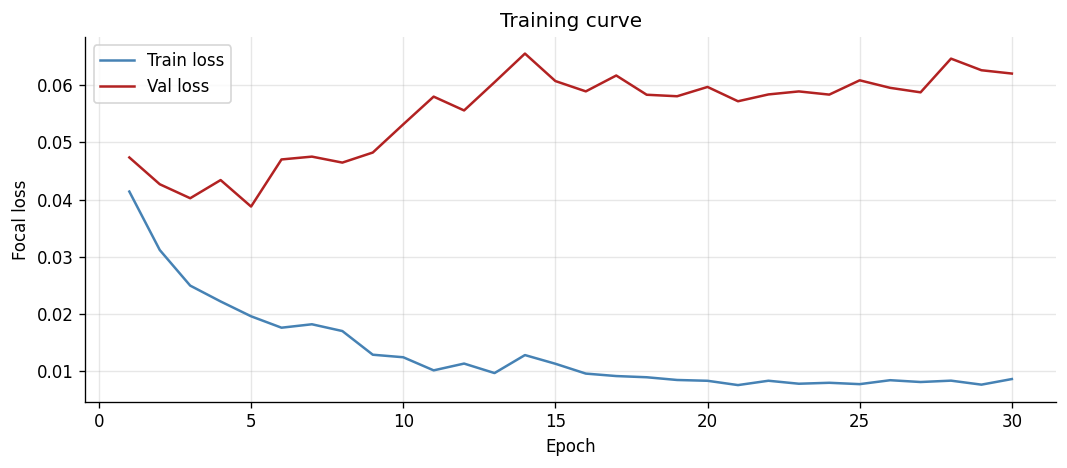

In [9]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, N_EPOCHS + 1), train_losses, label='Train loss', color='steelblue')
ax.plot(range(1, N_EPOCHS + 1), val_losses,   label='Val loss',   color='firebrick')
ax.set_xlabel('Epoch')
ax.set_ylabel('Focal loss')
ax.set_title('Training curve')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig_training_curve.png', bbox_inches='tight', dpi=150)
plt.show()

## 8 Prediction Visualisation

Below we visualise predicted fire probability maps against the ground-truth burn masks for a selection of validation patches.

**Important context on interpreting these results:** Fire prediction is an inherently difficult problem. Even state-of-the-art models trained on far larger datasets struggle with spatial precision. The most meaningful metric here is not pixel accuracy (which is dominated by the majority non-fire class) but **recall on fire pixels**, the model's ability to flag genuine fire risk without missing events. This demonstration uses a small dataset specifically to validate the pipeline; a production model would require the full multi-year dataset and a deeper temporal architecture (U-TAE).

In [14]:
model.eval()
THRESHOLD = 0.35   # tuned toward recall — asymmetric cost of missing a fire

# Collect predictions for the validation set
all_preds, all_labels_flat = [], []

with torch.no_grad():
    for xb, yb in val_loader:
        prob = model(xb.to(device)).cpu().numpy()  # (B, 1, H, W)
        all_preds.append(prob)
        all_labels_flat.append(yb.numpy())

preds_np  = np.concatenate(all_preds,        axis=0)  # (N, 1, H, W)
labels_np = np.concatenate(all_labels_flat,  axis=0)

binary_preds = (preds_np > THRESHOLD).astype(np.float32)

print(classification_report(
    labels_np.flatten().astype(int),
    binary_preds.flatten().astype(int),
    target_names=['No fire', 'Fire'],
    digits=3,
))

              precision    recall  f1-score   support

     No fire      0.903     0.909     0.906    104482
        Fire      0.002     0.002     0.002     10206

    accuracy                          0.828    114688
   macro avg      0.453     0.456     0.454    114688
weighted avg      0.823     0.828     0.826    114688



In [16]:
# Find val patches that actually contain fire pixels
fire_indices = [
    i for i in range(len(labels_np)) 
    if labels_np[i, 0].mean() > 0.01   # at least 1% burned
]

if len(fire_indices) == 0:
    print("No fire patches in validation set — showing first 4 patches instead")
    show_indices = list(range(min(4, len(labels_np))))
else:
    show_indices = fire_indices[:4]
    print(f"Showing {len(show_indices)} patches with fire pixels")

Showing 3 patches with fire pixels


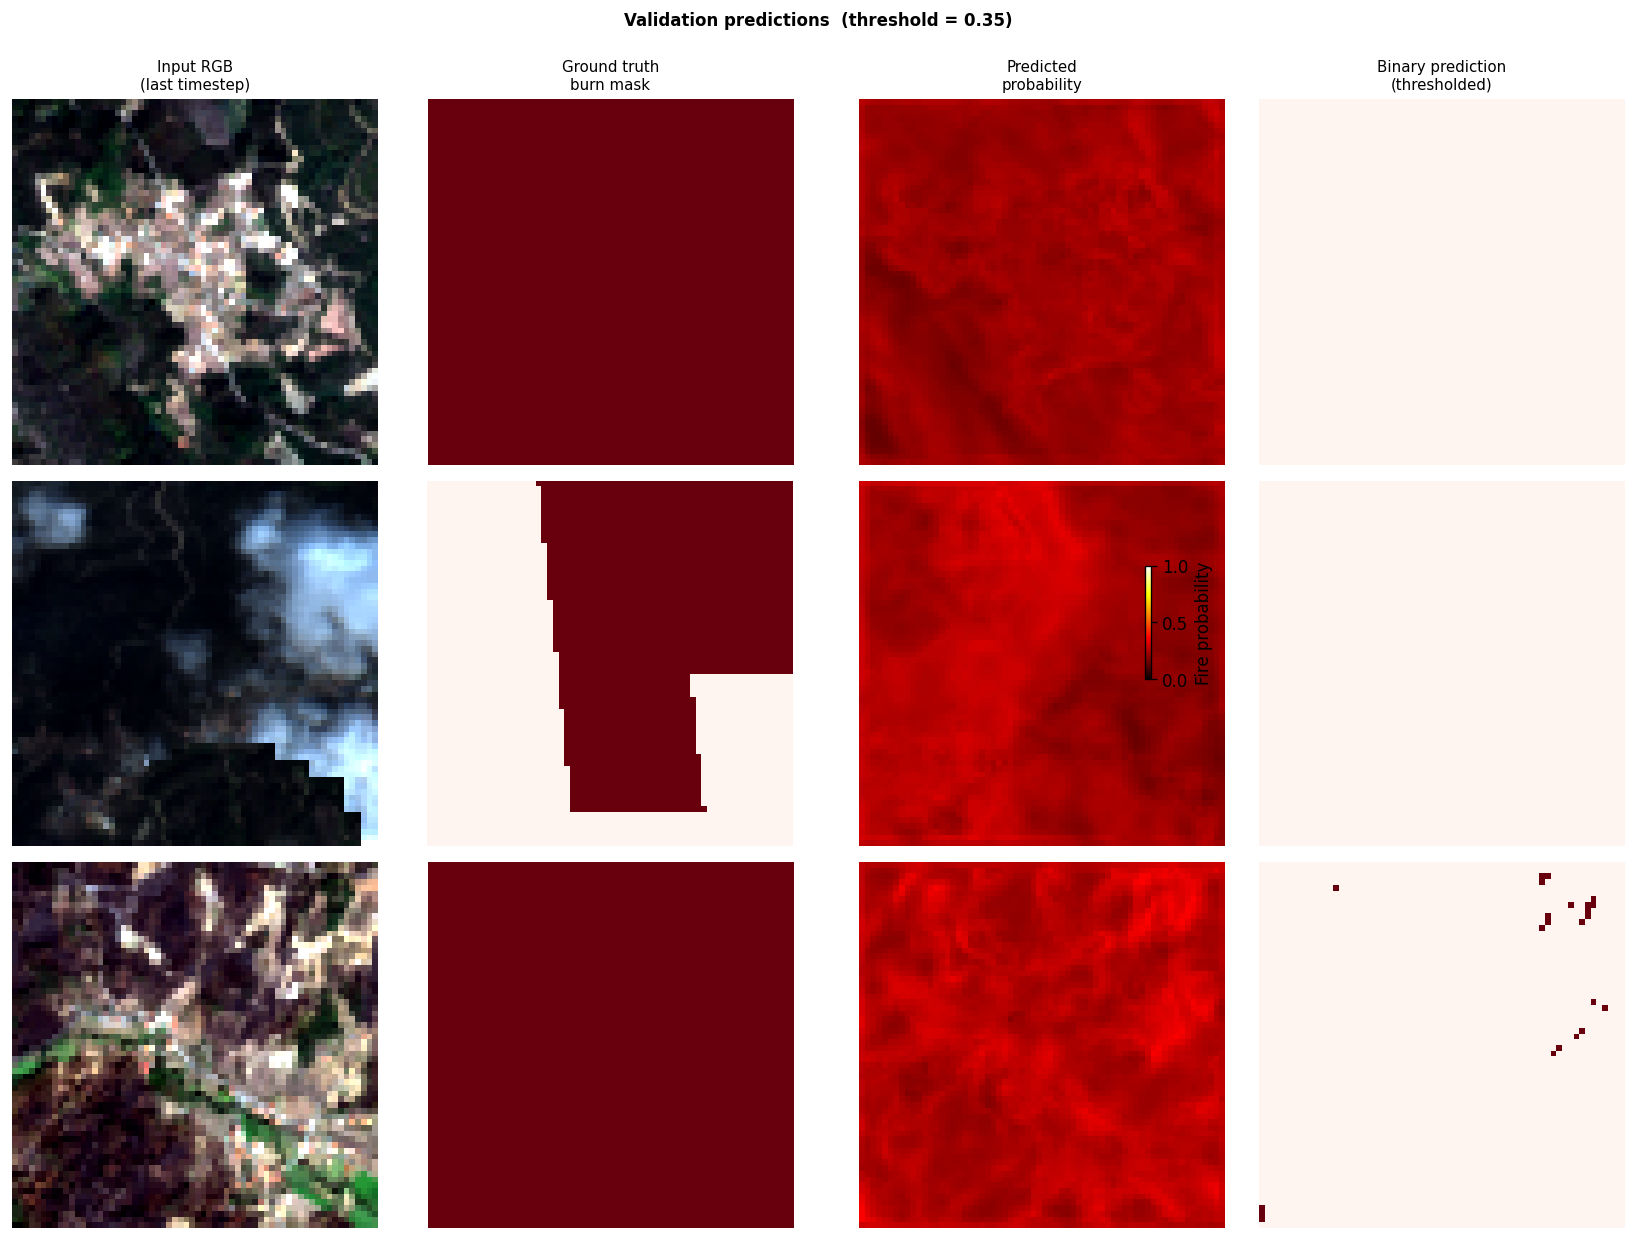

In [30]:
N_SHOW = len(show_indices)

fig, axes = plt.subplots(N_SHOW, 4, figsize=(14, N_SHOW * 3.5))
# Ensure axes is always 2D even when N_SHOW == 1
if N_SHOW == 1:
    axes = axes[np.newaxis, :]

fig.suptitle(
    f'Validation predictions  (threshold = {THRESHOLD})\n',
    fontsize=10, fontweight='bold'
)

col_titles = ['Input RGB\n(last timestep)', 'Ground truth\nburn mask',
              'Predicted\nprobability', 'Binary prediction\n(thresholded)']

for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=9)

for row, idx in enumerate(show_indices):
    last_frame = X_val[idx, -1].permute(1, 2, 0).numpy()
    rgb        = percentile_stretch(last_frame[:, :, :3])
    gt         = labels_np[idx, 0]
    prob_map   = preds_np[idx, 0]
    binary     = binary_preds[idx, 0]

    axes[row, 0].imshow(rgb)
    axes[row, 1].imshow(gt,       cmap='Reds', vmin=0, vmax=1)
    im = axes[row, 2].imshow(prob_map, cmap='hot', vmin=0, vmax=1)
    axes[row, 3].imshow(binary,   cmap='Reds', vmin=0, vmax=1)

    fire_pct = gt.mean() * 100
    axes[row, 0].set_ylabel(f'Patch {row+1}\n({fire_pct:.1f}% burned)', fontsize=8)

    for ax in axes[row]:
        ax.axis('off')

plt.colorbar(im, ax=axes[:, 2].tolist(), fraction=0.02, label='Fire probability')
plt.tight_layout()
plt.savefig('fig_predictions.png', bbox_inches='tight', dpi=150)
plt.show()

## Summary

This notebook has demonstrated a complete geospatial image analysis pipeline:

| Component | Implementation |
|-----------|---------------|
| Data source | Google Earth Engine — Sentinel-2, MODIS LST, MODIS MCD64A1, SRTM |
| Bands | 10-channel multiband stack (spectral, derived indices, thermal, topographic) |
| Streaming | `computePixels` API — no local file storage required |
| Sampling | Stratified fire/non-fire with spatial block train/val split |
| Temporal | 6-step bi-weekly composite sequences across the fire season |
| Model | ConvLSTM encoder + convolutional decoder for pixel-level segmentation |
| Loss | Binary focal loss with class-weight adjustment for severe imbalance |

**Limitations and next steps:** The small-scale training demo is intentionally limited in scope. The full pipeline supports streaming the complete 2015–2025 dataset with stratified sampling and is designed to scale to the U-TAE architecture, which uses learned temporal attention to weight timesteps differently per pixel. Performance metrics should be interpreted in that context. Fire prediction at pixel level is a genuinely hard problem even in the research literature, and meaningful results require the full multi-year dataset.